🎯 Starting Agile Sprint 2: Feature Engineering
✅ Data loaded successfully! Shape: (7043, 20)
🔧 Starting feature engineering process...
🔧 Creating new features...
✅ New features created! New shape: (7043, 26)

📈 Analyzing feature importance...

🏆 Top 10 Most Important Features:
         feature  importance
    charge_ratio    0.153862
  MonthlyCharges    0.142356
    TotalCharges    0.134920
          tenure    0.101761
contract_encoded    0.052514
        Contract    0.044695
   PaymentMethod    0.042885
  OnlineSecurity    0.036912
  total_services    0.034087
     TechSupport    0.033115

📊 Visualizing new features...


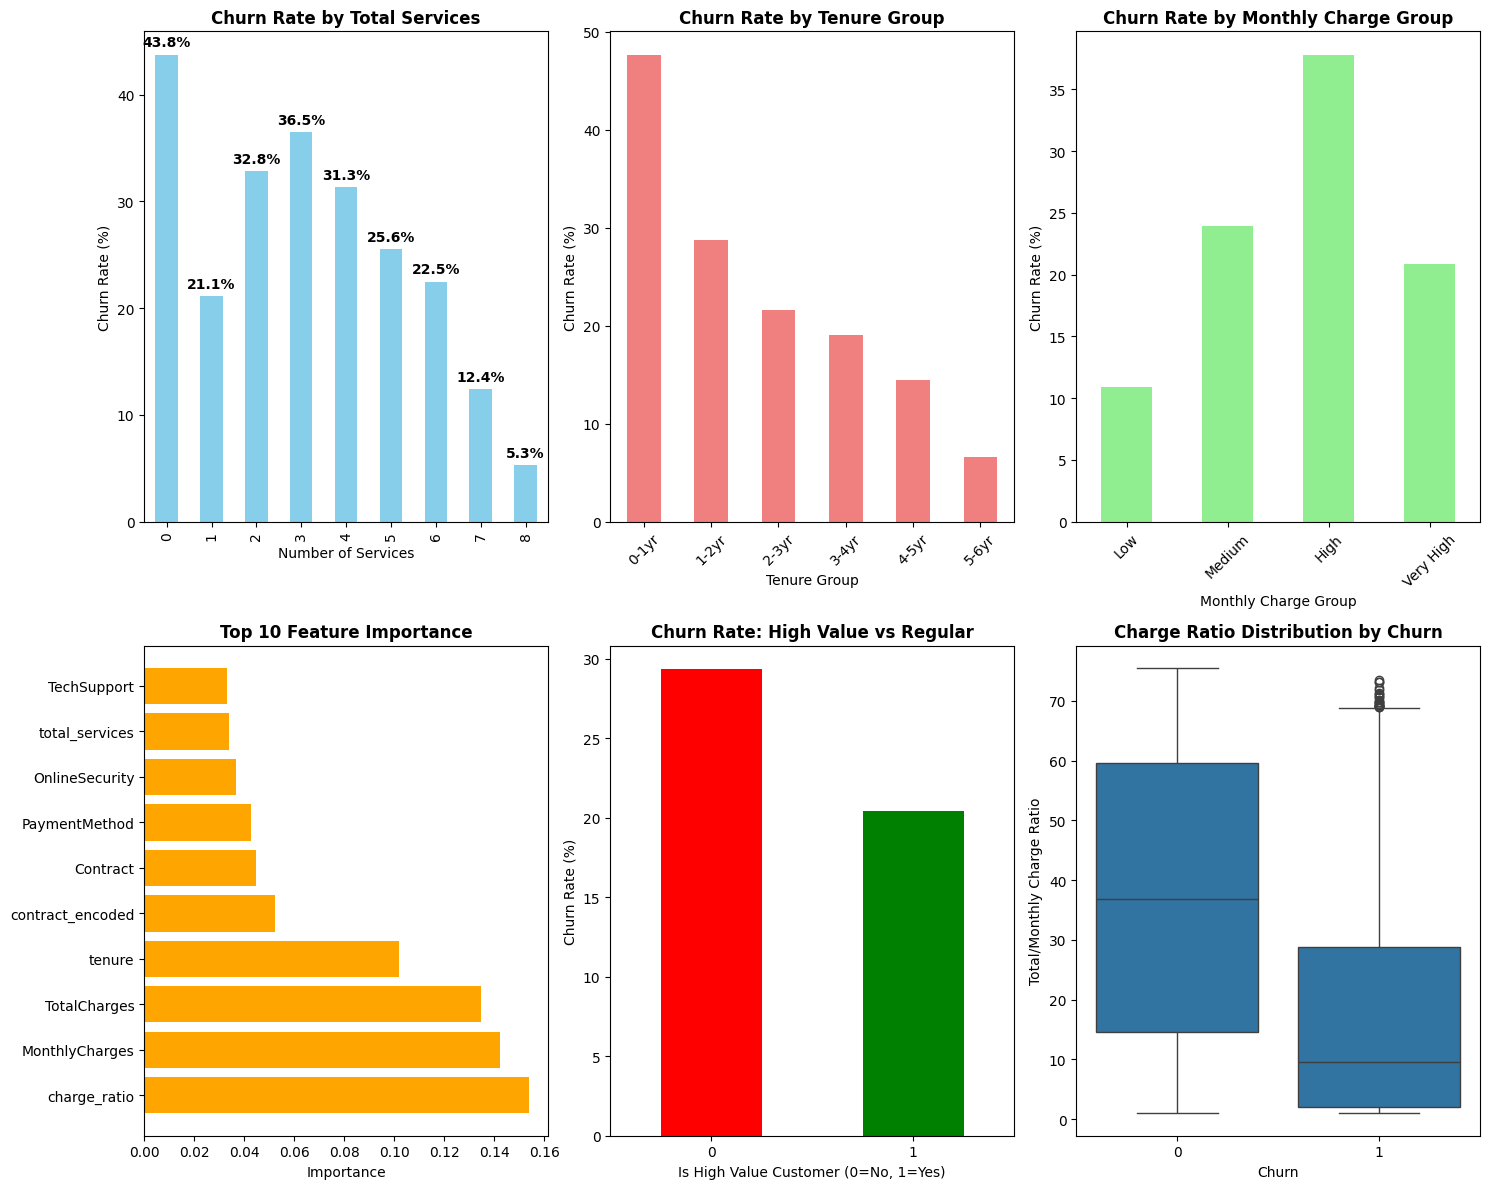

💾 Engineered data saved to: ../data/processed/engineered_churn_data.csv
📊 Final dataset shape: (7043, 26)
🎯 Features: 26

🎉 FEATURE ENGINEERING COMPLETED!
✅ New features created and analyzed
✅ Feature importance calculated
✅ Visualizations saved
✅ Engineered dataset saved

🚀 Ready for advanced model training!


In [1]:
# notebooks/03_feature_engineering.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

print("🎯 Starting Agile Sprint 2: Feature Engineering")
print("=" * 60)

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_churn_data.csv')
print(f"✅ Data loaded successfully! Shape: {df.shape}")

class FeatureEngineer:
    def __init__(self, data):
        self.df = data.copy()
        self.feature_importance = {}
        
    def create_new_features(self):
        """Create new engineered features"""
        print("🔧 Creating new features...")
        
        # 1. Tenure Groups
        self.df['tenure_group'] = pd.cut(self.df['tenure'], 
                                       bins=[0, 12, 24, 36, 48, 60, 72],
                                       labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', '5-6yr'])
        
        # 2. Monthly Charge Groups
        self.df['monthly_charge_group'] = pd.cut(self.df['MonthlyCharges'],
                                               bins=[0, 35, 70, 105, 140],
                                               labels=['Low', 'Medium', 'High', 'Very High'])
        
        # 3. Total Charge to Monthly Charge Ratio
        self.df['charge_ratio'] = self.df['TotalCharges'] / (self.df['MonthlyCharges'] + 1)
        
        # 4. Service Count (kitne services use kar raha hai customer)
        services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
        
        self.df['total_services'] = 0
        for service in services:
            self.df['total_services'] += (self.df[service].isin(['Yes'])).astype(int)
        
        # 5. Is High Value Customer?
        self.df['is_high_value'] = ((self.df['MonthlyCharges'] > 70) & 
                                  (self.df['tenure'] > 24)).astype(int)
        
        # 6. Contract Type Encoding (Month-to-month highest churn)
        contract_map = {'Month-to-month': 2, 'One year': 1, 'Two year': 0}
        self.df['contract_encoded'] = self.df['Contract'].map(contract_map)
        
        print(f"✅ New features created! New shape: {self.df.shape}")
        return self.df
    
    def analyze_feature_importance(self, target='Churn'):
        """Analyze feature importance with target"""
        from sklearn.ensemble import RandomForestClassifier
        
        # Prepare data for feature importance
        df_encoded = self.df.copy()
        
        # Encode categorical variables
        categorical_cols = df_encoded.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            df_encoded[col] = df_encoded[col].astype('category').cat.codes
        
        X = df_encoded.drop(target, axis=1)
        y = df_encoded[target]
        
        # Remove non-numeric columns for feature importance
        X = X.select_dtypes(include=[np.number])
        
        # Train Random Forest for feature importance
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        # Get feature importance
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        self.feature_importance = feature_importance
        return feature_importance
    
    def visualize_new_features(self):
        """Visualize newly created features"""
        print("\n📊 Visualizing new features...")
        
        # 1. Total Services vs Churn
        plt.figure(figsize=(15, 12))
        
        plt.subplot(2, 3, 1)
        service_churn = self.df.groupby('total_services')['Churn'].mean() * 100
        service_churn.plot(kind='bar', color='skyblue')
        plt.title('Churn Rate by Total Services', fontweight='bold')
        plt.xlabel('Number of Services')
        plt.ylabel('Churn Rate (%)')
        
        # Add percentage labels
        for i, v in enumerate(service_churn):
            plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # 2. Tenure Groups vs Churn
        plt.subplot(2, 3, 2)
        tenure_churn = self.df.groupby('tenure_group')['Churn'].mean() * 100
        tenure_churn.plot(kind='bar', color='lightcoral')
        plt.title('Churn Rate by Tenure Group', fontweight='bold')
        plt.xlabel('Tenure Group')
        plt.ylabel('Churn Rate (%)')
        plt.xticks(rotation=45)
        
        # 3. Monthly Charge Groups vs Churn
        plt.subplot(2, 3, 3)
        charge_churn = self.df.groupby('monthly_charge_group')['Churn'].mean() * 100
        charge_churn.plot(kind='bar', color='lightgreen')
        plt.title('Churn Rate by Monthly Charge Group', fontweight='bold')
        plt.xlabel('Monthly Charge Group')
        plt.ylabel('Churn Rate (%)')
        plt.xticks(rotation=45)
        
        # 4. Feature Importance
        plt.subplot(2, 3, 4)
        top_features = self.feature_importance.head(10)
        plt.barh(top_features['feature'], top_features['importance'], color='orange')
        plt.title('Top 10 Feature Importance', fontweight='bold')
        plt.xlabel('Importance')
        
        # 5. High Value Customers
        plt.subplot(2, 3, 5)
        high_value_churn = self.df.groupby('is_high_value')['Churn'].mean() * 100
        high_value_churn.plot(kind='bar', color=['red', 'green'])
        plt.title('Churn Rate: High Value vs Regular', fontweight='bold')
        plt.xlabel('Is High Value Customer (0=No, 1=Yes)')
        plt.ylabel('Churn Rate (%)')
        plt.xticks(rotation=0)
        
        # 6. Charge Ratio Distribution
        plt.subplot(2, 3, 6)
        sns.boxplot(data=self.df, x='Churn', y='charge_ratio')
        plt.title('Charge Ratio Distribution by Churn', fontweight='bold')
        plt.xlabel('Churn')
        plt.ylabel('Total/Monthly Charge Ratio')
        
        plt.tight_layout()
        plt.savefig('../models/model_performance/feature_engineering_insights.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
    
    def save_engineered_data(self, save_path):
        """Save dataset with engineered features"""
        self.df.to_csv(save_path, index=False)
        print(f"💾 Engineered data saved to: {save_path}")
        print(f"📊 Final dataset shape: {self.df.shape}")
        print(f"🎯 Features: {len(self.df.columns)}")

# Execute Feature Engineering
print("🔧 Starting feature engineering process...")
feature_engineer = FeatureEngineer(df)

# Create new features
df_engineered = feature_engineer.create_new_features()

# Analyze feature importance
print("\n📈 Analyzing feature importance...")
importance_df = feature_engineer.analyze_feature_importance()
print("\n🏆 Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Visualize results
feature_engineer.visualize_new_features()

# Save engineered data
feature_engineer.save_engineered_data('../data/processed/engineered_churn_data.csv')

print("\n🎉 FEATURE ENGINEERING COMPLETED!")
print("=" * 50)
print("✅ New features created and analyzed")
print("✅ Feature importance calculated") 
print("✅ Visualizations saved")
print("✅ Engineered dataset saved")
print("\n🚀 Ready for advanced model training!")